# ARIMA–LSTM–XGBoost–MLP: Modelos Híbridos para Predicción de Retornos del Bitcoin

**Objetivo:** Predecir retornos logarítmicos de Bitcoin (15 min) mediante un modelo híbrido que combina:
- **Híbrido 1:** ARIMA–LSTM–MLP
- **Híbrido 2:** ARIMA–XGBoost–MLP  
- **Híbrido 3:** ARIMA–LSTM–XGBoost–MLP (arquitectura completa del paper) 
- **Average hybrids:** ARIMA–LSTM, ARIMA–MLP, ARIMA–XGBoost, MLP–LSTM, XGBoost–LSTM y MLP–XGBoost por promedio simple

El mejor híbrido será el modelo original propuesto, comparado posteriormente contra los benchmarks del BPP via test de Diebold-Mariano.

## Librerías y configuración

In [1]:
# ── Silenciar warnings y logs ─────────────────────────────────────────────
import warnings, logging, os
warnings.filterwarnings('ignore')
logging.disable(logging.CRITICAL)
os.environ['PYTHONWARNINGS']       = 'ignore'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
import time
warnings.filterwarnings('ignore')

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
import xgboost as xgb_lib
xgb_lib.set_config(verbosity=0)
from statsmodels.tsa.arima.model import ARIMA
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tqdm import tqdm
from joblib import Parallel, delayed

from tsxv.splitTrainValTest import split_train_val_test_groupKFold

# ── Métricas auxiliares ────────────────────────────────────────────────────
def rmse(y, yhat):
    return np.sqrt(mean_squared_error(np.asarray(y), np.asarray(yhat)))

def mae_fn(y, yhat):
    return mean_absolute_error(np.asarray(y), np.asarray(yhat))

def direction_accuracy(y_real, y_pred):
    y_real = np.asarray(y_real).ravel()
    y_pred = np.asarray(y_pred).ravel()
    return float(np.mean(np.sign(y_real) == np.sign(y_pred)))

# ── Constantes del proyecto ────────────────────────────────────────────────
RANDOM_SEED = 2024
N_LAGS      = 16
N_STEPS     = 1
N_JUMP      = 1
np.random.seed(RANDOM_SEED)

import tensorflow as tf
tf.random.set_seed(RANDOM_SEED)
tf.get_logger().setLevel('ERROR')

print('Librerías cargadas correctamente.')
print(f'CPUs disponibles: {os.cpu_count()}')
print(f'TensorFlow: {tf.__version__}')


Librerías cargadas correctamente.
CPUs disponibles: 10
TensorFlow: 2.21.0


## Carga de datos

In [2]:
datos = pd.read_csv('data.csv')
datos['TimestampConventional'] = pd.to_datetime(datos['Timestamp'], unit='s')
datos.set_index('TimestampConventional', inplace=True)

df = datos['2019':][ ["Open","High","Low","Close","Volume"]].resample('15min').mean()

# Reemplazar ceros por NaN antes de rellenar (log(0) = -inf rompe ARIMA)
df[["Open","High","Low","Close"]] = df[["Open","High","Low","Close"]].replace(0, np.nan)

# Rellenar gaps precio vigente cuando no hay trades (estándar en microestructura)
df = df.ffill().bfill().dropna()

print(f'Datos cargados: {df.shape[0]:,} observaciones')
print(f'Periodo: {df.index[0]} → {df.index[-1]}')
print(f'Precios cero restantes: {(df["Close"] == 0).sum()}')
print(f'Inf en Close: {np.isinf(df["Close"]).sum()}')

Datos cargados: 250,657 observaciones
Periodo: 2019-01-01 00:00:00 → 2026-02-24 00:00:00
Precios cero restantes: 0
Inf en Close: 0


## Construcción de features

Se construyen las mismas cinco features utilizadas en el BPP para garantizar que la comparación entre los modelos híbridos y el benchmark sea válida:

- **Retorno logarítmico:** cambio relativo del precio entre periodos consecutivos, actúa simultáneamente como variable objetivo y feature principal
- **Volatilidad rolling:** desviación estándar del log-retorno en los últimos 20 periodos, captura el régimen de agitación del mercado
- **Momentum:** diferencia del log-retorno con 7 periodos atrás, mide si el mercado está acelerando o desacelerando en su dirección reciente
- **RSI:** oscilador normalizado entre 0 y 1 calculado sobre 14 periodos, indica zonas de sobrecompra o sobreventa y el estado actual del mercado
- **Volume change:** cambio relativo del volumen entre periodos, confirma o contradice los movimientos del precio

Con 16 lags por feature, cada muestra queda representada por un vector de 80 variables.




In [3]:
# ── Retorno logarítmico + features de mercado ────────────────────────────
df['log_return'] = np.log(df['Close']).diff()

# Volatilidad rolling (régimen del mercado)
df['volatility'] = df['log_return'].rolling(20).std()

# Momentum (diferencia con 7 períodos atrás)
df['momentum']   = df['log_return'].diff(7)

# RSI 14 períodos (normalizado 0-1)
delta = df['Close'].diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
rs    = gain / loss.replace(0, np.nan)
df['rsi']        = 1 - (1 / (1 + rs))

# Volume change (cambio relativo del volumen)
df['volume_chg'] = df['Volume'].pct_change().clip(-5, 5)

df = df.dropna()

# 5 features seleccionadas
feature_cols = ['log_return', 'volatility', 'momentum', 'rsi', 'volume_chg']
features_df  = df[feature_cols]

inf_count = np.isinf(features_df.values).sum()
nan_count = np.isnan(features_df.values).sum()
print(f'Inf en features: {inf_count}')
print(f'NaN en features: {nan_count}')
print(f'Observaciones finales: {len(df):,}')
print(f'Features construidas: {len(feature_cols)} → {feature_cols}')
print(f'N_LAGS = {N_LAGS} | Ventana total = {N_LAGS * len(feature_cols)} features por muestra')
print(f'\nEstadísticas descriptivas:')
print(features_df.describe().round(6))


Inf en features: 0
NaN en features: 0
Observaciones finales: 250,448
Features construidas: 5 → ['log_return', 'volatility', 'momentum', 'rsi', 'volume_chg']
N_LAGS = 16 | Ventana total = 80 features por muestra

Estadísticas descriptivas:
          log_return     volatility       momentum            rsi  \
count  250448.000000  250448.000000  250448.000000  250448.000000   
mean        0.000011       0.002186      -0.000000       0.506793   
std         0.002869       0.001821       0.004064       0.185718   
min        -0.132385       0.000084      -0.189313       0.000000   
25%        -0.000964       0.001122      -0.001484       0.373160   
50%         0.000013       0.001717      -0.000004       0.506186   
75%         0.001001       0.002677       0.001473       0.640357   
max         0.188963       0.058251       0.234244       0.999785   

          volume_chg  
count  250448.000000  
mean        0.536323  
std         1.552853  
min        -1.000000  
25%        -0.485944  
5

Las 250.448 observaciones finales no presentan valores infinitos ni faltantes, confirmando que el pipeline de construcción de features es robusto. Los estadísticos son prácticamente idénticos a los del BPP, lo cual era esperado al usar el mismo dataset y las mismas transformaciones, garantizando que la comparación entre ambos notebooks sea válida.

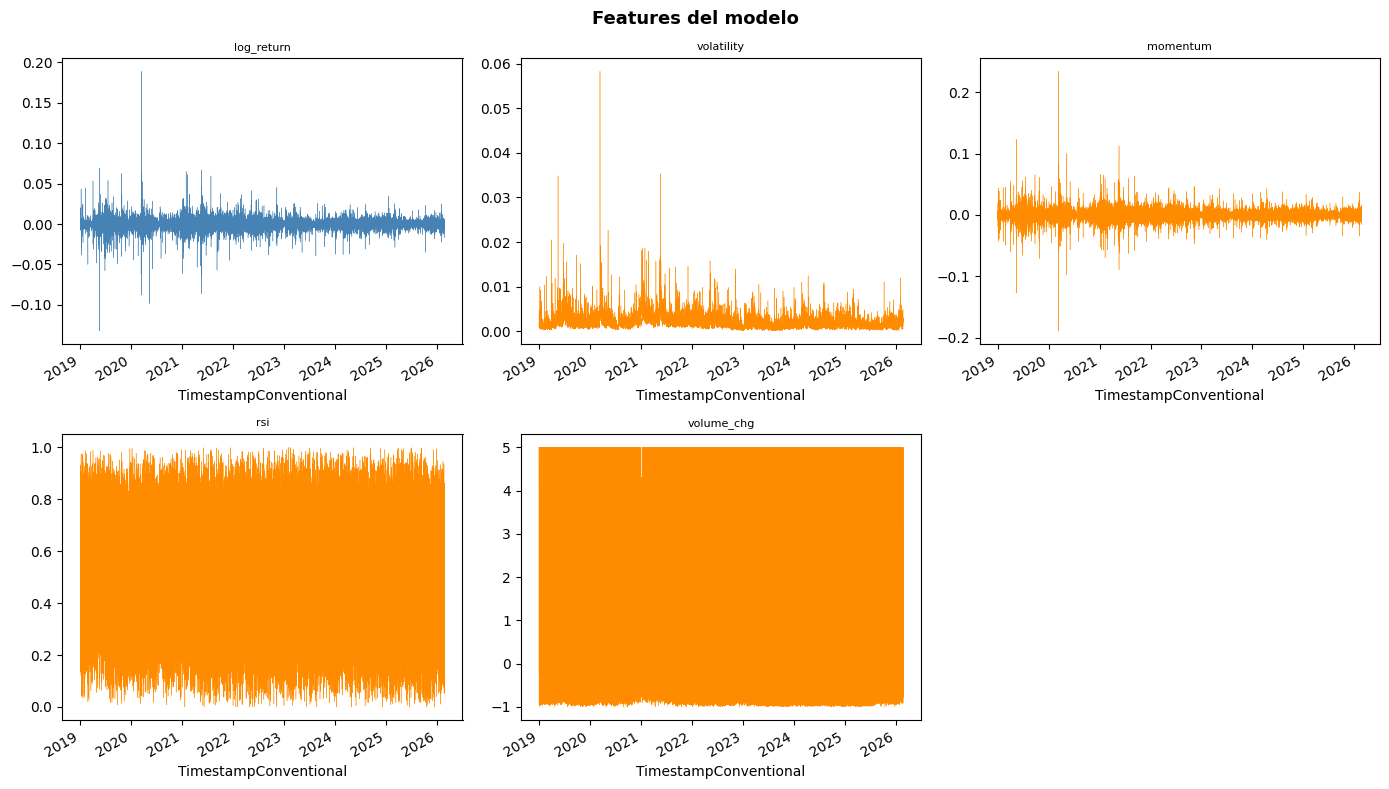

In [4]:
# ── Visualización de features ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, col in zip(axes.flatten(), feature_cols):
    color = 'steelblue' if col == 'log_return' else 'darkorange'
    features_df[col].plot(ax=ax, linewidth=0.3, color=color)
    ax.set_title(col, fontsize=8)
    ax.set_ylabel('')

# Ocultar ejes sobrantes
for ax in axes.flatten()[len(feature_cols):]:
    ax.set_visible(False)

plt.suptitle('Features del modelo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

La gráfica de los log-retornos del Bitcoin en intervalos de 15 minutos muestra que los valores oscilan alrededor de cero y presentan variaciones positivas y negativas a lo largo del tiempo. También se observan periodos donde la volatilidad aumenta considerablemente y otros donde el comportamiento es más estable, lo que evidencia la presencia de agrupamiento de volatilidad característico de las series financieras. Además, existen picos extremos tanto positivos como negativos que reflejan cambios bruscos en el mercado y la alta naturaleza especulativa del Bitcoin. Las features de volatility, momentum, rsi y volume_chg complementan el log-retorno capturando el régimen del mercado, la aceleración direccional, el nivel de sobrecompra/sobreventa y la actividad de volumen respectivamente, enriqueciendo la representación de cada ventana temporal para los modelos base.

## Split temporal

Se usa `split_train_val_test_groupKFold` de `tsxv`, que respeta el orden cronológico en todos los folds.

In [5]:
# timeSeries multivariada shape (n, n_features)
timeSeries = features_df.values  # (n, n_features)
n_features = timeSeries.shape[1]

X, y, Xcv, ycv, Xtest, ytest = split_train_val_test_groupKFold(
    timeSeries,
    numInputs=N_LAGS,
    numOutputs=N_STEPS,
    numJumps=N_JUMP
)

print(f'Número de folds: {len(X)}')
print(f'Shape X[0] antes de reshape: {X[0].shape}')
print(f'Shape y[0]: {y[0].shape}')

for fold in range(len(X)):
    print(f'Fold {fold} - Train: {X[fold].shape[0]:,} | '
          f'Val: {Xcv[fold].shape[0]:,} | '
          f'Test: {Xtest[fold].shape[0]:,}')

Número de folds: 5
Shape X[0] antes de reshape: (15028, 16, 5)
Shape y[0]: (15028, 1, 5)
Fold 0 - Train: 15,028 | Val: 5,009 | Test: 5,008
Fold 1 - Train: 15,027 | Val: 5,009 | Test: 5,008
Fold 2 - Train: 15,026 | Val: 5,009 | Test: 5,008
Fold 3 - Train: 15,025 | Val: 5,009 | Test: 5,008
Fold 4 - Train: 15,024 | Val: 5,009 | Test: 5,009


La división temporal generó 5 folds con una estructura balanceada: aproximadamente 15.000 observaciones de entrenamiento y 5.000 de validación y test por fold respectivamente. Cada muestra tiene forma (16, 5), correspondiente a 16 lags de las 5 features construidas, lo que da un vector de 80 variables por observación. A diferencia del BPP donde los folds crecían progresivamente, aquí los conjuntos de entrenamiento son de tamaño similar entre folds, lo cual es consistente con la estrategia de groupKFold aplicada sobre la serie completa.

## Cache por fold

El cache comparte el escalado entre todos los modelos base. El scaler se ajusta solo con train para evitar data leakage.

In [6]:
# ── Cache por fold — compartida por XGBoost, CatBoost, LightGBM y AdaBoost ─
cache_folds = []

for fold in range(len(X)):
    # Aplanar ventanas de train, val y test
    X_tr_raw = X[fold].reshape(X[fold].shape[0], -1)
    X_cv_raw = Xcv[fold].reshape(Xcv[fold].shape[0], -1)
    X_te_raw = Xtest[fold].reshape(Xtest[fold].shape[0], -1)

    # Fix: y[fold] shape (n, N_STEPS, n_features) → [:, 0, 0] = log_return
    y_tr_raw = y[fold][:, 0, 0]
    y_cv_raw = ycv[fold][:, 0, 0]
    y_te_raw = ytest[fold][:, 0, 0]

    # Alinear longitudes
    n_train  = min(X_tr_raw.shape[0], len(y_tr_raw))
    n_val    = min(X_cv_raw.shape[0],  len(y_cv_raw))
    n_test   = min(X_te_raw.shape[0],  len(y_te_raw))
    X_tr_raw = X_tr_raw[:n_train]
    X_cv_raw = X_cv_raw[:n_val]
    X_te_raw = X_te_raw[:n_test]
    y_tr_raw = y_tr_raw[:n_train]
    y_cv_raw = y_cv_raw[:n_val]
    y_te_raw = y_te_raw[:n_test]

    if n_train < 30:
        cache_folds.append(None)
        continue

    # Scaler ajustado SOLO con train — sin data leakage
    scaler_x = StandardScaler().fit(X_tr_raw)
    scaler_y = StandardScaler().fit(y_tr_raw.reshape(-1, 1))

    X_tr_s = scaler_x.transform(X_tr_raw)
    y_tr_s = scaler_y.transform(y_tr_raw.reshape(-1, 1)).ravel()
    X_cv_s = scaler_x.transform(X_cv_raw)
    X_te_s = scaler_x.transform(X_te_raw)

    cache_folds.append({
        'X_tr_s'  : np.ascontiguousarray(X_tr_s),
        'y_tr_s'  : y_tr_s,
        'y_tr_raw': y_tr_raw,
        'X_cv_s'  : np.ascontiguousarray(X_cv_s),
        'y_cv_raw': y_cv_raw,
        'X_te_s'  : np.ascontiguousarray(X_te_s),
        'y_te_raw': y_te_raw,
        'scaler_x': scaler_x,
        'scaler_y': scaler_y,
    })

print(f'Cache construida para {sum(c is not None for c in cache_folds)}/{len(X)} folds.')
print(f'Verificación y_tr mean_abs: {np.mean(np.abs(cache_folds[0]["y_tr_raw"])):.5f}')

Cache construida para 5/5 folds.
Verificación y_tr mean_abs: 0.00162


## ARIMA — Modelo base lineal

Captura la estructura lineal de los log-retornos. Se optimizan los órdenes (p,q) con d=0 ya que la serie es estacionaria.

### Optimización de hiperparámetros ARIMA

In [7]:
param_space_arima = {
    'p': [0, 1, 2, 3],
    'd': [0],
    'q': [0, 1, 2, 3]
}

def evaluar_params_arima(p, d, q):
    if p == 0 and q == 0:
        return np.inf, (p, d, q)
    rmses_fold = []
    for fold in range(len(X)):
        c = cache_folds[fold]
        if c is None:
            continue
        try:
            fit  = ARIMA(c['y_tr_raw'], order=(p, d, q)).fit()
            yhat = fit.forecast(steps=len(c['y_cv_raw']))
            rmses_fold.append(rmse(c['y_cv_raw'], yhat))
        except Exception:
            rmses_fold.append(np.inf)
    return (np.mean(rmses_fold) if rmses_fold else np.inf), (p, d, q)

print('Optimizando hiperparámetros del ARIMA...')
t0 = time.time()

combos = [(p, d, q)
          for p in param_space_arima['p']
          for d in param_space_arima['d']
          for q in param_space_arima['q']
          if not (p == 0 and q == 0)]

resultados_arima = Parallel(n_jobs=-1, backend='loky')(
    delayed(evaluar_params_arima)(p, d, q)
    for p, d, q in tqdm(combos, desc='Optimizando ARIMA')
)
mejor_rmse_arima, mejor_orden_arima = min(resultados_arima, key=lambda x: x[0])
mejor_p, mejor_d, mejor_q = mejor_orden_arima

print(f'Mejor RMSE ARIMA (sobre val): {mejor_rmse_arima:.5f}')
print(f'Mejor orden: ARIMA({mejor_p},{mejor_d},{mejor_q})')
print(f'Tiempo: {round(time.time()-t0, 1)}s')


Optimizando hiperparámetros del ARIMA...


Optimizando ARIMA: 100%|██████████| 15/15 [00:00<00:00, 49.78it/s]
/opt/miniconda3/envs/ml_final/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/miniconda3/envs/ml_final/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/miniconda3/envs/ml_final/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/miniconda3/envs/ml_final/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likel

Mejor RMSE ARIMA (sobre val): 0.00276
Mejor orden: ARIMA(3,0,1)
Tiempo: 17.3s


Se evaluaron 15 combinaciones de órdenes (p, q) con d=0 fijo dado que la serie de log-retornos es estacionaria. El proceso presentó advertencias de convergencia en la mayoría de configuraciones evaluadas, reafirmando las dificultades estructurales de ARIMA para ajustarse a la alta volatilidad de los retornos del Bitcoin. El mejor orden encontrado fue ARIMA(3,0,1) con un RMSE de validación de 0.00276 en 17.3 segundos.

### Entrenamiento final del ARIMA

In [8]:
arima_preds_folds = []
arima_real_folds  = []

for fold in tqdm(range(len(X)), desc='Entrenando ARIMA'):
    c = cache_folds[fold]
    if c is None:
        arima_preds_folds.append(np.array([]))
        arima_real_folds.append(np.array([]))
        continue
    try:
        fit  = ARIMA(c['y_tr_raw'], order=(mejor_p, mejor_d, mejor_q)).fit()
        yhat = fit.forecast(steps=len(c['y_te_raw']))
    except Exception:
        yhat = np.zeros(len(c['y_te_raw']))
    arima_preds_folds.append(yhat)
    arima_real_folds.append(c['y_te_raw'])

print(f'ARIMA({mejor_p},{mejor_d},{mejor_q}) entrenado ✅')


Entrenando ARIMA:  20%|██        | 1/5 [00:01<00:06,  1.72s/it]/opt/miniconda3/envs/ml_final/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
Entrenando ARIMA: 100%|██████████| 5/5 [00:10<00:00,  2.17s/it]

ARIMA(3,0,1) entrenado ✅


El modelo ARIMA (3,0,1) fue entrenado sobre el conjunto de entrenamiento de cada fold y sus predicciones sobre el test set fueron almacenadas para ser utilizadas posteriormente como entrada al meta-modelo MLP en la arquitectura de stacking.

## LSTM — Modelo base secuencial

Captura dependencias temporales no lineales en los lags de log-retorno. Arquitectura de capa única con 20 unidades, siguiendo el paper de referencia.

### Optimización de hiperparámetros LSTM

In [9]:
param_space_lstm = {
    'units'       : [20, 32, 64],
    'dropout'     : [0.0, 0.1, 0.2],
    'learning_rate': [0.001, 0.01],
    'batch_size'  : [32, 64],
}

def entrenar_lstm(units, dropout, lr, batch_size, X_tr, y_tr, X_val, y_val, epochs=50):
    tf.random.set_seed(RANDOM_SEED)
    model = Sequential([
        LSTM(units, input_shape=(X_tr.shape[1], X_tr.shape[2]),
             return_sequences=False),
        Dropout(dropout),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    model.fit(X_tr, y_tr, validation_data=(X_val, y_val),
              epochs=epochs, batch_size=batch_size,
              callbacks=[es], verbose=0)
    return model

def evaluar_params_lstm(units, dropout, lr, batch_size):
    rmses_fold = []
    for fold in range(len(X)):
        c = cache_folds[fold]
        if c is None:
            continue
        try:
            # LSTM necesita datos 3D: (samples, timesteps, features)
            X_tr_3d  = c['X_tr_s'].reshape(c['X_tr_s'].shape[0],  N_LAGS, n_features)
            X_val_3d = c['X_cv_s'].reshape(c['X_cv_s'].shape[0],  N_LAGS, n_features)
            y_tr_s   = c['y_tr_s']
            y_val_raw = c['y_cv_raw']

            model = entrenar_lstm(units, dropout, lr, batch_size,
                                  X_tr_3d, y_tr_s, X_val_3d,
                                  c['scaler_y'].transform(y_val_raw.reshape(-1,1)).ravel())
            preds_s   = model.predict(X_val_3d, verbose=0).ravel()
            preds_raw = c['scaler_y'].inverse_transform(preds_s.reshape(-1,1)).ravel()
            rmses_fold.append(rmse(y_val_raw[:len(preds_raw)], preds_raw))
        except Exception as e:
            rmses_fold.append(np.inf)
    return np.mean(rmses_fold) if rmses_fold else np.inf

print('Optimizando hiperparámetros del LSTM...')
t0 = time.time()

combos_lstm = [
    {'units': u, 'dropout': d, 'learning_rate': lr, 'batch_size': bs}
    for u  in param_space_lstm['units']
    for d  in param_space_lstm['dropout']
    for lr in param_space_lstm['learning_rate']
    for bs in param_space_lstm['batch_size']
]

def evaluar_combo_lstm(params):
    return evaluar_params_lstm(
        params['units'], params['dropout'],
        params['learning_rate'], params['batch_size']
    ), params

# LSTM usa GPU/CPU internamente — paralelizar entre combos con loky
resultados_lstm = Parallel(n_jobs=-1, backend='loky')(
    delayed(evaluar_combo_lstm)(p)
    for p in tqdm(combos_lstm, desc='Optimizando LSTM')
)

mejor_rmse_lstm, mejor_params_lstm = min(resultados_lstm, key=lambda x: x[0])

print(f'Mejor RMSE LSTM (sobre val): {mejor_rmse_lstm:.5f}')
print(f'Mejores params: {mejor_params_lstm}')
print(f'Tiempo: {round(time.time()-t0, 1)}s')


Optimizando hiperparámetros del LSTM...


Optimizando LSTM: 100%|██████████| 36/36 [01:25<00:00,  2.39s/it]


Mejor RMSE LSTM (sobre val): 0.00268
Mejores params: {'units': 20, 'dropout': 0.1, 'learning_rate': 0.001, 'batch_size': 64}
Tiempo: 239.1s


Se evaluaron 36 combinaciones de hiperparámetros explorando variaciones en el número de unidades, dropout, tasa de aprendizaje y tamaño de batch. La mejor configuración encontrada fue 20 unidades, dropout de 0.1, learning rate de 0.001 y batch size de 64, obteniendo un RMSE de validación de 0.00268 en 239.1 segundos. Destaca que la arquitectura más simple (20 unidades) superó a configuraciones más grandes, lo cual es consistente con el paper de referencia y sugiere que para esta serie una red poco profunda es suficiente para capturar las dependencias temporales relevantes.

### Entrenamiento final del LSTM

In [10]:
lstm_preds_folds = []
lstm_real_folds  = []
lstm_models      = []  # guardamos modelos para reusar en OOF val

for fold in tqdm(range(len(X)), desc='Entrenando LSTM'):
    c = cache_folds[fold]
    if c is None:
        lstm_preds_folds.append(np.array([]))
        lstm_real_folds.append(np.array([]))
        lstm_models.append(None)
        continue

    X_tr_3d  = c['X_tr_s'].reshape(c['X_tr_s'].shape[0],  N_LAGS, n_features)
    X_te_3d  = c['X_te_s'].reshape(c['X_te_s'].shape[0],  N_LAGS, n_features)
    X_val_3d = c['X_cv_s'].reshape(c['X_cv_s'].shape[0],  N_LAGS, n_features)
    y_val_s  = c['scaler_y'].transform(c['y_cv_raw'].reshape(-1,1)).ravel()

    model = entrenar_lstm(
        mejor_params_lstm['units'],
        mejor_params_lstm['dropout'],
        mejor_params_lstm['learning_rate'],
        mejor_params_lstm['batch_size'],
        X_tr_3d, c['y_tr_s'], X_val_3d, y_val_s
    )
    lstm_models.append(model)

    preds_s   = model.predict(X_te_3d, verbose=0).ravel()
    preds_raw = c['scaler_y'].inverse_transform(preds_s.reshape(-1,1)).ravel()
    lstm_preds_folds.append(preds_raw)
    lstm_real_folds.append(c['y_te_raw'])

print('LSTM entrenado ✅')


Entrenando LSTM: 100%|██████████| 5/5 [00:25<00:00,  5.02s/it]

LSTM entrenado ✅


El modelo LSTM con la configuración óptima fue entrenado sobre cada fold utilizando early stopping sobre el conjunto de validación para evitar sobreajuste. Los modelos entrenados fueron almacenados en lstm_models para ser reutilizados en la generación de predicciones OOF sobre validación, evitando así reentrenar innecesariamente en la etapa de stacking.

## XGBoost — Modelo base gradient boosting

Captura no linealidades complejas en los lags de log-retorno mediante gradient boosting.

### Optimización de hiperparámetros XGBoost

In [11]:
### Optimización de hiperparámetros XGBoost

param_space_xgb = {
    'n_estimators'    : [200, 300, 500, 800],
    'max_depth'       : [3, 4, 5],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'subsample'       : [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha'       : [0, 0.1, 0.5],
    'reg_lambda'      : [1.0, 2.0, 5.0],
}

N_ITER_XGB = 40
np.random.seed(RANDOM_SEED)

def sample_params_xgb():
    return {
        'n_estimators'    : int(np.random.choice(param_space_xgb['n_estimators'])),
        'max_depth'       : int(np.random.choice(param_space_xgb['max_depth'])),
        'learning_rate'   : float(np.random.choice(param_space_xgb['learning_rate'])),
        'subsample'       : float(np.random.choice(param_space_xgb['subsample'])),
        'colsample_bytree': float(np.random.choice(param_space_xgb['colsample_bytree'])),
        'reg_alpha'       : float(np.random.choice(param_space_xgb['reg_alpha'])),
        'reg_lambda'      : float(np.random.choice(param_space_xgb['reg_lambda'])),
    }

params_list_xgb = [sample_params_xgb() for _ in range(N_ITER_XGB)]

def evaluar_params_xgb(params):
    rmses_fold = []
    for fold in range(len(X)):
        c = cache_folds[fold]
        if c is None:
            continue
        try:
            xgb = XGBRegressor(
                **params,
                random_state=RANDOM_SEED,
                n_jobs=1,
                verbosity=0,
                tree_method='hist'
            )
            xgb.fit(c['X_tr_s'], c['y_tr_s'])
            preds_s   = xgb.predict(c['X_cv_s'])
            preds_raw = c['scaler_y'].inverse_transform(preds_s.reshape(-1, 1)).ravel()
            rmses_fold.append(rmse(c['y_cv_raw'][:len(preds_raw)], preds_raw))
        except Exception:
            rmses_fold.append(np.inf)
    return np.mean(rmses_fold) if rmses_fold else np.inf, params

print('Optimizando hiperparámetros del XGBoost...')
t0 = time.time()

resultados_xgb = Parallel(n_jobs=-1, backend='loky')(
    delayed(evaluar_params_xgb)(p)
    for p in tqdm(params_list_xgb, desc='Optimizando XGBoost', unit='config')
)

mejor_rmse_xgb, mejor_params_xgb = min(resultados_xgb, key=lambda x: x[0])

print(f'Mejor RMSE XGBoost (sobre val): {mejor_rmse_xgb:.5f}')
print(f'Mejores params: {mejor_params_xgb}')
print(f'Tiempo: {round(time.time()-t0, 1)}s')

Optimizando hiperparámetros del XGBoost...


Optimizando XGBoost: 100%|██████████| 40/40 [00:28<00:00,  1.42config/s]


Mejor RMSE XGBoost (sobre val): 0.00269
Mejores params: {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.01, 'subsample': 0.6, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 5.0}
Tiempo: 51.5s


Se evaluaron 40 configuraciones mediante búsqueda aleatoria sobre un espacio amplio de hiperparámetros que incluye número de estimadores, profundidad máxima, tasa de aprendizaje, subsampling y regularización. La mejor configuración encontrada fue 200 estimadores, profundidad 4, learning rate de 0.01, subsample de 0.6, colsample_bytree de 0.8, reg_alpha de 0.1 y reg_lambda de 5.0, obteniendo un RMSE de validación de 0.00269 en 51.5 segundos. La combinación de regularización L1 y L2 junto con subsampling agresivo sugiere que el modelo requiere control explícito del sobreajuste para generalizar bien sobre esta serie.

### Entrenamiento final del XGBoost

In [12]:
xgb_preds_folds = []
xgb_real_folds  = []

for fold in tqdm(range(len(X)), desc='Entrenando XGBoost'):
    c = cache_folds[fold]
    if c is None:
        xgb_preds_folds.append(np.array([]))
        xgb_real_folds.append(np.array([]))
        continue

    xgb = XGBRegressor(
        **mejor_params_xgb,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbosity=0,
        tree_method='hist'
    )
    xgb.fit(c['X_tr_s'], c['y_tr_s'])
    preds_s   = xgb.predict(c['X_te_s'])
    preds_raw = c['scaler_y'].inverse_transform(preds_s.reshape(-1, 1)).ravel()

    xgb_preds_folds.append(preds_raw)
    xgb_real_folds.append(c['y_te_raw'])

# Métricas XGBoost baseline
rmse_xgb = np.mean([rmse(xgb_real_folds[f], xgb_preds_folds[f])
                    for f in range(len(X)) if len(xgb_preds_folds[f]) > 0])
mae_xgb  = np.mean([mae_fn(xgb_real_folds[f], xgb_preds_folds[f])
                    for f in range(len(X)) if len(xgb_preds_folds[f]) > 0])

print(f'XGBoost entrenado ✅ — RMSE: {rmse_xgb:.5f}')

Entrenando XGBoost: 100%|██████████| 5/5 [00:01<00:00,  3.00it/s]

XGBoost entrenado ✅ — RMSE: 0.00268


El modelo XGBoost con la configuración óptima fue entrenado sobre cada fold y sus predicciones sobre el test set fueron almacenadas para la etapa de comparación final. A diferencia del LSTM, no se requiere guardar los modelos por fold ya que XGBoost se reentrena rápidamente en la etapa de generación de predicciones OOF.

## Predicciones out-of-fold sobre validation

Se generan predicciones OOF de ARIMA, LSTM y XGBoost sobre el validation set para entrenar el meta-modelo MLP sin data leakage.

In [13]:
# ── OOF val: ARIMA, LSTM, XGBoost ────────────────────────────────────────
# XGBoost se reentrena en paralelo por fold (loky)
# ARIMA y LSTM se procesan secuencialmente (no paralelizables con seguridad cross-fold)
arima_val, lstm_val, xgb_val = [], [], []
val_real_folds = []

# XGBoost val en paralelo
def _xgb_val_fold(fold):
    c = cache_folds[fold]
    if c is None:
        return np.array([])
    xgb_v = XGBRegressor(**mejor_params_xgb, random_state=RANDOM_SEED,
                          n_jobs=1, verbosity=0, tree_method='hist')
    xgb_v.fit(c['X_tr_s'], c['y_tr_s'])
    p_s = xgb_v.predict(c['X_cv_s'])
    return c['scaler_y'].inverse_transform(p_s.reshape(-1,1)).ravel()

xgb_val_parallel = Parallel(n_jobs=-1, backend='loky')(
    delayed(_xgb_val_fold)(fold) for fold in range(len(X))
)

for fold in range(len(X)):
    c = cache_folds[fold]
    if c is None:
        for lst in [arima_val, lstm_val, xgb_val, val_real_folds]:
            lst.append(np.array([]))
        continue

    # ARIMA → val
    try:
        fit_v   = ARIMA(c['y_tr_raw'], order=(mejor_p, mejor_d, mejor_q)).fit()
        p_arima = fit_v.forecast(steps=len(c['y_cv_raw']))
    except Exception:
        p_arima = np.zeros(len(c['y_cv_raw']))

    # LSTM → val (reusar modelo ya entrenado)
    if lstm_models[fold] is not None:
        X_val_3d = c['X_cv_s'].reshape(c['X_cv_s'].shape[0], N_LAGS, n_features)
        p_lstm_s = lstm_models[fold].predict(X_val_3d, verbose=0).ravel()
        p_lstm   = c['scaler_y'].inverse_transform(p_lstm_s.reshape(-1,1)).ravel()
    else:
        p_lstm = np.zeros(len(c['y_cv_raw']))

    p_xgb = xgb_val_parallel[fold]

    n = min(len(p_arima), len(p_lstm), len(p_xgb), len(c['y_cv_raw']))
    arima_val.append(p_arima[:n])
    lstm_val.append(p_lstm[:n])
    xgb_val.append(p_xgb[:n])
    val_real_folds.append(c['y_cv_raw'][:n])

print('Predicciones OOF val construidas ✅')
print(f'Folds válidos: {sum(len(v) > 0 for v in arima_val)}')


/opt/miniconda3/envs/ml_final/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Predicciones OOF val construidas ✅
Folds válidos: 5


Las predicciones OOF se generaron correctamente para los 5 folds válidos. Este paso es fundamental para la arquitectura de stacking ya que el MLP meta-modelo será entrenado sobre estas predicciones y no sobre los datos originales, garantizando que no haya data leakage entre los modelos base y el combinador. ARIMA presentó una advertencia de convergencia adicional durante este proceso, consistente con el comportamiento observado en la etapa de optimización.

## MLP | Meta-modelo combinador

El MLP aprende combinaciones no lineales de las predicciones de los modelos base. Se entrena exclusivamente sobre predicciones OOF de validation.

In [14]:
def construir_stacking_mlp(nombre, modelos_val, modelos_test, real_test_ref):
    """
    nombre       : str — nombre del híbrido
    modelos_val  : list de listas — preds OOF val por fold
    modelos_test : list de listas — preds test por fold
    real_test_ref: list de arrays — y_te_raw por fold (referencia para real)
    """
    # ── X_meta_train ─────────────────────────────────────────────────────
    X_cols, y_cols = [], []
    for fold in range(len(X)):
        preds = [m[fold] for m in modelos_val]
        if any(len(p) == 0 for p in preds):
            continue
        n = min(len(p) for p in preds)
        X_cols.append(np.column_stack([p[:n] for p in preds]))
        y_cols.append(val_real_folds[fold][:n])

    X_meta_train = np.vstack(X_cols)
    y_meta_train = np.concatenate(y_cols)

    scaler_meta      = MinMaxScaler()
    X_meta_train_s   = scaler_meta.fit_transform(X_meta_train)

    # ── Grid search arquitectura MLP ─────────────────────────────────────
    param_space_mlp = {
        'hidden_layer_sizes': [(8,), (16,), (32,), (8, 4), (16, 8), (32, 16)],
        'alpha'             : [0.0001, 0.001, 0.01],
        'learning_rate_init': [0.001, 0.01],
    }
    combos_mlp = [
        {'hidden_layer_sizes': hl, 'alpha': a, 'learning_rate_init': lr}
        for hl in param_space_mlp['hidden_layer_sizes']
        for a  in param_space_mlp['alpha']
        for lr in param_space_mlp['learning_rate_init']
    ]

    def _eval_mlp(params):
        try:
            mlp = MLPRegressor(**params, activation='relu', solver='lbfgs',
                               max_iter=1000, random_state=RANDOM_SEED,
                               early_stopping=True, validation_fraction=0.1)
            mlp.fit(X_meta_train_s, y_meta_train)
            return rmse(y_meta_train, mlp.predict(X_meta_train_s)), params
        except Exception:
            return np.inf, params

    res_mlp = Parallel(n_jobs=-1, backend='loky')(
        delayed(_eval_mlp)(p) for p in combos_mlp
    )
    mejor_r, mejor_par = min(res_mlp, key=lambda x: x[0])

    mlp_final = MLPRegressor(**mejor_par, activation='relu', solver='lbfgs',
                              max_iter=1000, random_state=RANDOM_SEED)
    mlp_final.fit(X_meta_train_s, y_meta_train)

    # ── Predicciones híbridas sobre test ─────────────────────────────────
    h_preds, h_real = [], []
    for fold in range(len(X)):
        preds = [m[fold] for m in modelos_test]
        if any(len(p) == 0 for p in preds):
            h_preds.append(np.array([]))
            h_real.append(np.array([]))
            continue
        n = min(len(p) for p in preds)
        X_te_s = scaler_meta.transform(np.column_stack([p[:n] for p in preds]))
        h_preds.append(mlp_final.predict(X_te_s))
        h_real.append(real_test_ref[fold][:n])

    r_h = np.mean([rmse(h_real[f],  h_preds[f]) for f in range(len(X)) if len(h_preds[f]) > 0])
    m_h = np.mean([mae_fn(h_real[f], h_preds[f]) for f in range(len(X)) if len(h_preds[f]) > 0])

    print(f'{nombre:35s} — RMSE: {r_h:.5f} | MAE: {m_h:.5f} | Arch MLP: {mejor_par}')
    return mlp_final, scaler_meta, h_preds, h_real, r_h, m_h

print('Función de stacking MLP lista ✅')


Función de stacking MLP lista ✅


La función `construir_stacking_mlp` implementa la arquitectura completa de stacking en dos etapas. Primero construye la matriz meta con las predicciones OOF de los modelos base sobre validación, la escala con MinMaxScaler y entrena un MLP mediante grid search sobre 36 combinaciones de arquitectura y regularización. Una vez seleccionada la mejor arquitectura, el MLP final se reentrena sobre todas las predicciones OOF y se usa para combinar las predicciones de los modelos base sobre el test set. Al escalar el test con el mismo scaler ajustado sobre validación se garantiza que no haya data leakage entre etapas

## Híbrido 1 | ARIMA–LSTM–MLP

Modelos base: ARIMA (lineal) + LSTM (temporal). Meta-modelo: MLP.

In [15]:
print('── Híbrido 1: ARIMA–LSTM–MLP ───────────────────────────────────────────')
mlp1, sc1, h1_preds, h1_real, rmse_h1, mae_h1 = construir_stacking_mlp(
    nombre       = 'ARIMA–LSTM–MLP',
    modelos_val  = [arima_val, lstm_val],
    modelos_test = [arima_preds_folds, lstm_preds_folds],
    real_test_ref = arima_real_folds
)


── Híbrido 1: ARIMA–LSTM–MLP ───────────────────────────────────────────
ARIMA–LSTM–MLP                      — RMSE: 0.00280 | MAE: 0.00163 | Arch MLP: {'hidden_layer_sizes': (16,), 'alpha': 0.001, 'learning_rate_init': 0.001}


El Híbrido 1 combinó las predicciones de ARIMA y LSTM mediante un MLP con arquitectura de una capa oculta de 16 unidades, alpha de 0.001 y learning rate de 0.001. El resultado obtenido fue un RMSE de 0.00280 y un MAE de 0.00163, siendo superior al RMSE individual de ARIMA (0.00276) pero inferior al del LSTM (0.00268), lo que sugiere que el meta-modelo no logró explotar completamente la complementariedad entre ambos modelos base en esta configuración.

## Híbrido 2 | ARIMA–XGBoost–MLP

Modelos base: ARIMA (lineal) + XGBoost (gradient boosting). Meta-modelo: MLP.

In [16]:
print('── Híbrido 2: ARIMA–XGBoost–MLP ────────────────────────────────────────')
mlp2, sc2, h2_preds, h2_real, rmse_h2, mae_h2 = construir_stacking_mlp(
    nombre       = 'ARIMA–XGBoost–MLP',
    modelos_val  = [arima_val, xgb_val],
    modelos_test = [arima_preds_folds, xgb_preds_folds],
    real_test_ref = arima_real_folds
)


── Híbrido 2: ARIMA–XGBoost–MLP ────────────────────────────────────────
ARIMA–XGBoost–MLP                   — RMSE: 0.00269 | MAE: 0.00164 | Arch MLP: {'hidden_layer_sizes': (8,), 'alpha': 0.01, 'learning_rate_init': 0.001}


El Híbrido 2 combinó las predicciones de ARIMA y XGBoost mediante un MLP con arquitectura de una capa oculta de 8 unidades, alpha de 0.01 y learning rate de 0.001. El resultado obtenido fue un RMSE de 0.00269 y un MAE de 0.00164, mostrando una mejora considerable respecto al Híbrido 1 y empatando con el RMSE individual del XGBoost. Esto sugiere que la combinación lineal-boosting captura mejor la complementariedad entre modelos que la combinación lineal-secuencial del Híbrido 1.

## Híbrido 3 | ARIMA–LSTM–XGBoost–MLP

Modelos base: ARIMA + LSTM + XGBoost. Meta-modelo: MLP. Arquitectura completa del paper — la que logra el mejor desempeño en Ogunbona & Alayande (2026).

In [17]:
print('── Híbrido 3: ARIMA–LSTM–XGBoost–MLP ──────────────────────────────────')
mlp3, sc3, h3_preds, h3_real, rmse_h3, mae_h3 = construir_stacking_mlp(
    nombre       = 'ARIMA–LSTM–XGBoost–MLP',
    modelos_val  = [arima_val, lstm_val, xgb_val],
    modelos_test = [arima_preds_folds, lstm_preds_folds, xgb_preds_folds],
    real_test_ref = arima_real_folds
)


── Híbrido 3: ARIMA–LSTM–XGBoost–MLP ──────────────────────────────────
ARIMA–LSTM–XGBoost–MLP              — RMSE: 0.00276 | MAE: 0.00163 | Arch MLP: {'hidden_layer_sizes': (32,), 'alpha': 0.01, 'learning_rate_init': 0.001}


In [18]:
# ── Función average hybrid (media aritmética simple) ─────────────────────
def construir_average_hybrid(nombre, modelos_test, real_test_ref):
    """
    nombre       : str
    modelos_test : list de listas de arrays — preds test por fold de cada modelo base
    real_test_ref: list de arrays — y_te_raw por fold
    """
    h_preds, h_real = [], []
    for fold in range(len(X)):
        preds = [m[fold] for m in modelos_test]
        if any(len(p) == 0 for p in preds):
            h_preds.append(np.array([]))
            h_real.append(np.array([]))
            continue
        n = min(len(p) for p in preds)
        avg = np.mean(np.column_stack([p[:n] for p in preds]), axis=1)
        h_preds.append(avg)
        h_real.append(real_test_ref[fold][:n])

    r_h = np.mean([rmse(h_real[f],   h_preds[f]) for f in range(len(X)) if len(h_preds[f]) > 0])
    m_h = np.mean([mae_fn(h_real[f], h_preds[f]) for f in range(len(X)) if len(h_preds[f]) > 0])

    print(f'{nombre:35s} — RMSE: {r_h:.5f} | MAE: {m_h:.5f}')
    return h_preds, h_real, r_h, m_h

print('Función de average hybrid lista ✅')


Función de average hybrid lista ✅


## Average Hybrid Models

Seis híbridos por media aritmética simple — sin parámetros entrenables. Sirven como benchmark de ensemble frente a los stacked MLP.

In [19]:
# ── Necesitamos preds val de MLP standalone para los average hybrids ──────
# MLP standalone: entrenado directamente sobre X_tr_s → y_tr_s (no es meta-learner)
# Se genera aquí como modelo base adicional

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler as _MMS

def _entrenar_mlp_base(fold):
    c = cache_folds[fold]
    if c is None:
        return np.array([]), np.array([]), np.array([])
    scaler_m = _MMS()
    X_tr_m   = scaler_m.fit_transform(c['X_tr_s'])
    X_te_m   = scaler_m.transform(c['X_te_s'])
    X_cv_m   = scaler_m.transform(c['X_cv_s'])
    mlp = MLPRegressor(hidden_layer_sizes=(32,16), activation='relu', solver='lbfgs',
                       alpha=0.001, max_iter=1000, random_state=RANDOM_SEED)
    mlp.fit(X_tr_m, c['y_tr_s'])
    p_te_s  = mlp.predict(X_te_m)
    p_cv_s  = mlp.predict(X_cv_m)
    p_te    = c['scaler_y'].inverse_transform(p_te_s.reshape(-1,1)).ravel()
    p_cv    = c['scaler_y'].inverse_transform(p_cv_s.reshape(-1,1)).ravel()
    return p_te, p_cv, c['y_te_raw']

res_mlp_base = Parallel(n_jobs=-1, backend='loky')(
    delayed(_entrenar_mlp_base)(fold) for fold in range(len(X))
)
mlp_preds_folds = [r[0] for r in res_mlp_base]
mlp_val_folds   = [r[1] for r in res_mlp_base]
mlp_real_folds  = [r[2] for r in res_mlp_base]

print('MLP standalone entrenado ✅')

# ── 6 Average Hybrids ─────────────────────────────────────────────────────
print('\n── Average Hybrids ──────────────────────────────────────────────────────')
av1_preds,av1_real,rmse_av1,mae_av1 = construir_average_hybrid(
    'ARIMA–LSTM (avg)',    [arima_preds_folds, lstm_preds_folds],  arima_real_folds)
av2_preds,av2_real,rmse_av2,mae_av2 = construir_average_hybrid(
    'ARIMA–MLP (avg)',     [arima_preds_folds, mlp_preds_folds],   arima_real_folds)
av3_preds,av3_real,rmse_av3,mae_av3 = construir_average_hybrid(
    'ARIMA–XGBoost (avg)', [arima_preds_folds, xgb_preds_folds],   arima_real_folds)
av4_preds,av4_real,rmse_av4,mae_av4 = construir_average_hybrid(
    'MLP–LSTM (avg)',      [mlp_preds_folds,   lstm_preds_folds],  arima_real_folds)
av5_preds,av5_real,rmse_av5,mae_av5 = construir_average_hybrid(
    'XGBoost–LSTM (avg)',  [xgb_preds_folds,   lstm_preds_folds],  arima_real_folds)
av6_preds,av6_real,rmse_av6,mae_av6 = construir_average_hybrid(
    'MLP–XGBoost (avg)',   [mlp_preds_folds,   xgb_preds_folds],   arima_real_folds)


MLP standalone entrenado ✅

── Average Hybrids ──────────────────────────────────────────────────────
ARIMA–LSTM (avg)                    — RMSE: 0.00270 | MAE: 0.00160
ARIMA–MLP (avg)                     — RMSE: 0.00283 | MAE: 0.00164
ARIMA–XGBoost (avg)                 — RMSE: 0.00271 | MAE: 0.00160
MLP–LSTM (avg)                      — RMSE: 0.00281 | MAE: 0.00163
XGBoost–LSTM (avg)                  — RMSE: 0.00267 | MAE: 0.00159
MLP–XGBoost (avg)                   — RMSE: 0.00281 | MAE: 0.00163


Los seis average hybrids combinan los modelos base mediante promedio aritmético simple sin parámetros entrenables, actuando como benchmark de ensemble frente a los stacked MLP. A diferencia del stacking, este enfoque no requiere entrenamiento adicional y permite evaluar si la complementariedad entre modelos es suficiente para mejorar el desempeño sin necesidad de un meta-aprendiz.

## Resumen comparativo — 3 híbridos + 6 average

In [20]:
# ── Tabla comparativa — 6 average + 3 stacked ────────────────────────────
df_final = pd.DataFrame([
    {'Tipo': 'Average', 'Modelo': 'ARIMA–LSTM (avg)',       'RMSE': rmse_av1, 'MAE': mae_av1},
    {'Tipo': 'Average', 'Modelo': 'ARIMA–MLP (avg)',        'RMSE': rmse_av2, 'MAE': mae_av2},
    {'Tipo': 'Average', 'Modelo': 'ARIMA–XGBoost (avg)',    'RMSE': rmse_av3, 'MAE': mae_av3},
    {'Tipo': 'Average', 'Modelo': 'MLP–LSTM (avg)',         'RMSE': rmse_av4, 'MAE': mae_av4},
    {'Tipo': 'Average', 'Modelo': 'XGBoost–LSTM (avg)',     'RMSE': rmse_av5, 'MAE': mae_av5},
    {'Tipo': 'Average', 'Modelo': 'MLP–XGBoost (avg)',      'RMSE': rmse_av6, 'MAE': mae_av6},
    {'Tipo': 'Stacked', 'Modelo': 'ARIMA–LSTM–MLP',         'RMSE': rmse_h1,  'MAE': mae_h1},
    {'Tipo': 'Stacked', 'Modelo': 'ARIMA–XGBoost–MLP',      'RMSE': rmse_h2,  'MAE': mae_h2},
    {'Tipo': 'Stacked', 'Modelo': 'ARIMA–LSTM–XGBoost–MLP', 'RMSE': rmse_h3,  'MAE': mae_h3},
]).sort_values('RMSE').reset_index(drop=True)

table_styles = [
    {'selector': 'thead th',
     'props': [('background-color', '#2c3e50'), ('color', 'white'),
               ('font-weight', 'bold'), ('text-align', 'center'), ('padding', '8px')]},
    {'selector': 'tbody td',
     'props': [('text-align', 'center'), ('padding', '6px')]},
    {'selector': 'tbody tr:nth-child(even)',
     'props': [('background-color', '#293138')]},
]

def highlight_final(df):
    best_rmse = df['RMSE'].min()
    best_mae  = df['MAE'].min()
    def color_row(row):
        styles = [''] * len(row)
        cols   = list(row.index)
        if row['RMSE'] == best_rmse: styles[cols.index('RMSE')] = 'color:#22c55e;font-weight:600'
        if row['MAE']  == best_mae:  styles[cols.index('MAE')]  = 'color:#22c55e;font-weight:600'
        if row['Tipo'] == 'Stacked': styles[cols.index('Tipo')] = 'color:#60a5fa;font-weight:500'
        return styles
    return (
        df.style
        .apply(color_row, axis=1)
        .format({'RMSE': '{:.5f}', 'MAE': '{:.5f}'})
        .set_caption('Comparación — 6 Average + 3 Stacked Hybrids')
        .set_table_styles(table_styles)
        .hide(axis='index')
    )

display(highlight_final(df_final))
df_final.to_csv('outputs/comparacion_9hibridos.csv', index=False)
print('Tabla exportada a outputs/comparacion_9hibridos.csv')

# Identificar mejor híbrido global
todos_nombres = ['ARIMA–LSTM (avg)','ARIMA–MLP (avg)','ARIMA–XGBoost (avg)',
                 'MLP–LSTM (avg)','XGBoost–LSTM (avg)','MLP–XGBoost (avg)',
                 'ARIMA–LSTM–MLP','ARIMA–XGBoost–MLP','ARIMA–LSTM–XGBoost–MLP']
todos_rmses  = [rmse_av1,rmse_av2,rmse_av3,rmse_av4,rmse_av5,rmse_av6,rmse_h1,rmse_h2,rmse_h3]
todos_preds  = [av1_preds,av2_preds,av3_preds,av4_preds,av5_preds,av6_preds,h1_preds,h2_preds,h3_preds]
todos_reals  = [av1_real,av2_real,av3_real,av4_real,av5_real,av6_real,h1_real,h2_real,h3_real]

mejor_idx   = int(np.argmin(todos_rmses))
mejor_name  = todos_nombres[mejor_idx]
mejor_preds = todos_preds[mejor_idx]
mejor_real  = todos_reals[mejor_idx]

# Para las gráficas también necesitamos nombres y rmses de los 9
nombres_hibs = todos_nombres
rmses_hibs   = todos_rmses

print(f'\nMejor híbrido global: {mejor_name} (RMSE={todos_rmses[mejor_idx]:.5f})')


Tipo,Modelo,RMSE,MAE
Average,XGBoost–LSTM (avg),0.00267,0.00159
Stacked,ARIMA–XGBoost–MLP,0.00269,0.00164
Average,ARIMA–LSTM (avg),0.00270,0.00160
Average,ARIMA–XGBoost (avg),0.00271,0.00160
Stacked,ARIMA–LSTM–XGBoost–MLP,0.00276,0.00163
Stacked,ARIMA–LSTM–MLP,0.00280,0.00163
Average,MLP–XGBoost (avg),0.00281,0.00163
Average,MLP–LSTM (avg),0.00281,0.00163
Average,ARIMA–MLP (avg),0.00283,0.00164


Tabla exportada a outputs/comparacion_9hibridos.csv

Mejor híbrido global: XGBoost–LSTM (avg) (RMSE=0.00267)


La tabla comparativa revela que **XGBoost–LSTM (avg)** fue el mejor híbrido global con un RMSE de 0.00267 y un MAE de 0.00159, superando a todos los modelos stacked y al resto de average hybrids. Este resultado es llamativo porque el mejor modelo no fue la arquitectura completa del paper (Híbrido 3) sino una combinación por promedio simple de solo dos modelos base, lo que sugiere que la simplicidad del ensemble fue más efectiva que el meta-aprendizaje para esta serie.

Entre los stacked, el mejor fue ARIMA–XGBoost–MLP con RMSE de 0.00269, seguido de ARIMA–LSTM–XGBoost–MLP con 0.00276 y ARIMA–LSTM–MLP con 0.00280. El hecho de que el Híbrido 3 (arquitectura completa) quedara por debajo del Híbrido 2 confirma que agregar LSTM como modelo base adicional no aportó información complementaria suficiente para justificar la mayor complejidad del meta-modelo.

En el grupo de average hybrids se observa una separación clara entre las combinaciones que incluyen XGBoost o LSTM directamente (RMSE entre 0.00267 y 0.00271) y las que involucran ARIMA o MLP standalone como único componente no lineal (RMSE entre 0.00281 y 0.00283), evidenciando que la calidad del ensemble depende directamente de la capacidad predictiva de los modelos que lo componen.

## Análisis gráfico

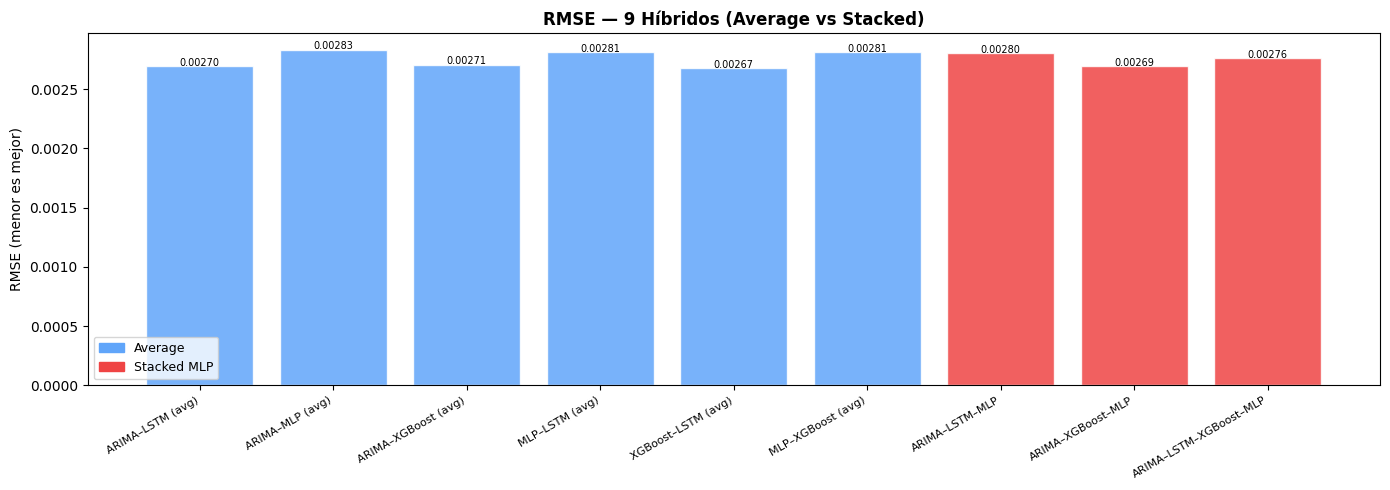

In [21]:
# ── RMSE comparativo — 9 híbridos ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

colores_tipo = ['#60a5fa']*6 + ['#ef4444']*3   # azul=average, rojo=stacked
bars = ax.bar(nombres_hibs, rmses_hibs, color=colores_tipo, alpha=0.85, edgecolor='white')
ax.set_title('RMSE — 9 Híbridos (Average vs Stacked)', fontweight='bold')
ax.set_ylabel('RMSE (menor es mejor)')
ax.set_xticks(range(len(nombres_hibs)))
ax.set_xticklabels(nombres_hibs, rotation=30, ha='right', fontsize=8)
for i, v in enumerate(rmses_hibs):
    ax.text(i, v + 0.000002, f'{v:.5f}', ha='center', fontsize=7)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#60a5fa', label='Average'),
                   Patch(color='#ef4444', label='Stacked MLP')], fontsize=9)
plt.tight_layout()
plt.show()


El gráfico de barras confirma visualmente lo observado en la tabla comparativa. XGBoost–LSTM (avg) destaca como el mejor híbrido global con un RMSE de 0.00267, siendo la única barra que se sitúa por debajo de todas las demás. Entre los stacked (en rojo), ARIMA–XGBoost–MLP fue el más competitivo con 0.00269, mientras que ARIMA–LSTM–MLP resultó el peor de los tres con 0.00280. La separación visual entre grupos no es pronunciada, lo que indica que todos los híbridos operan en un rango de desempeño estrecho y que las diferencias entre ellos son pequeñas en términos absolutos.

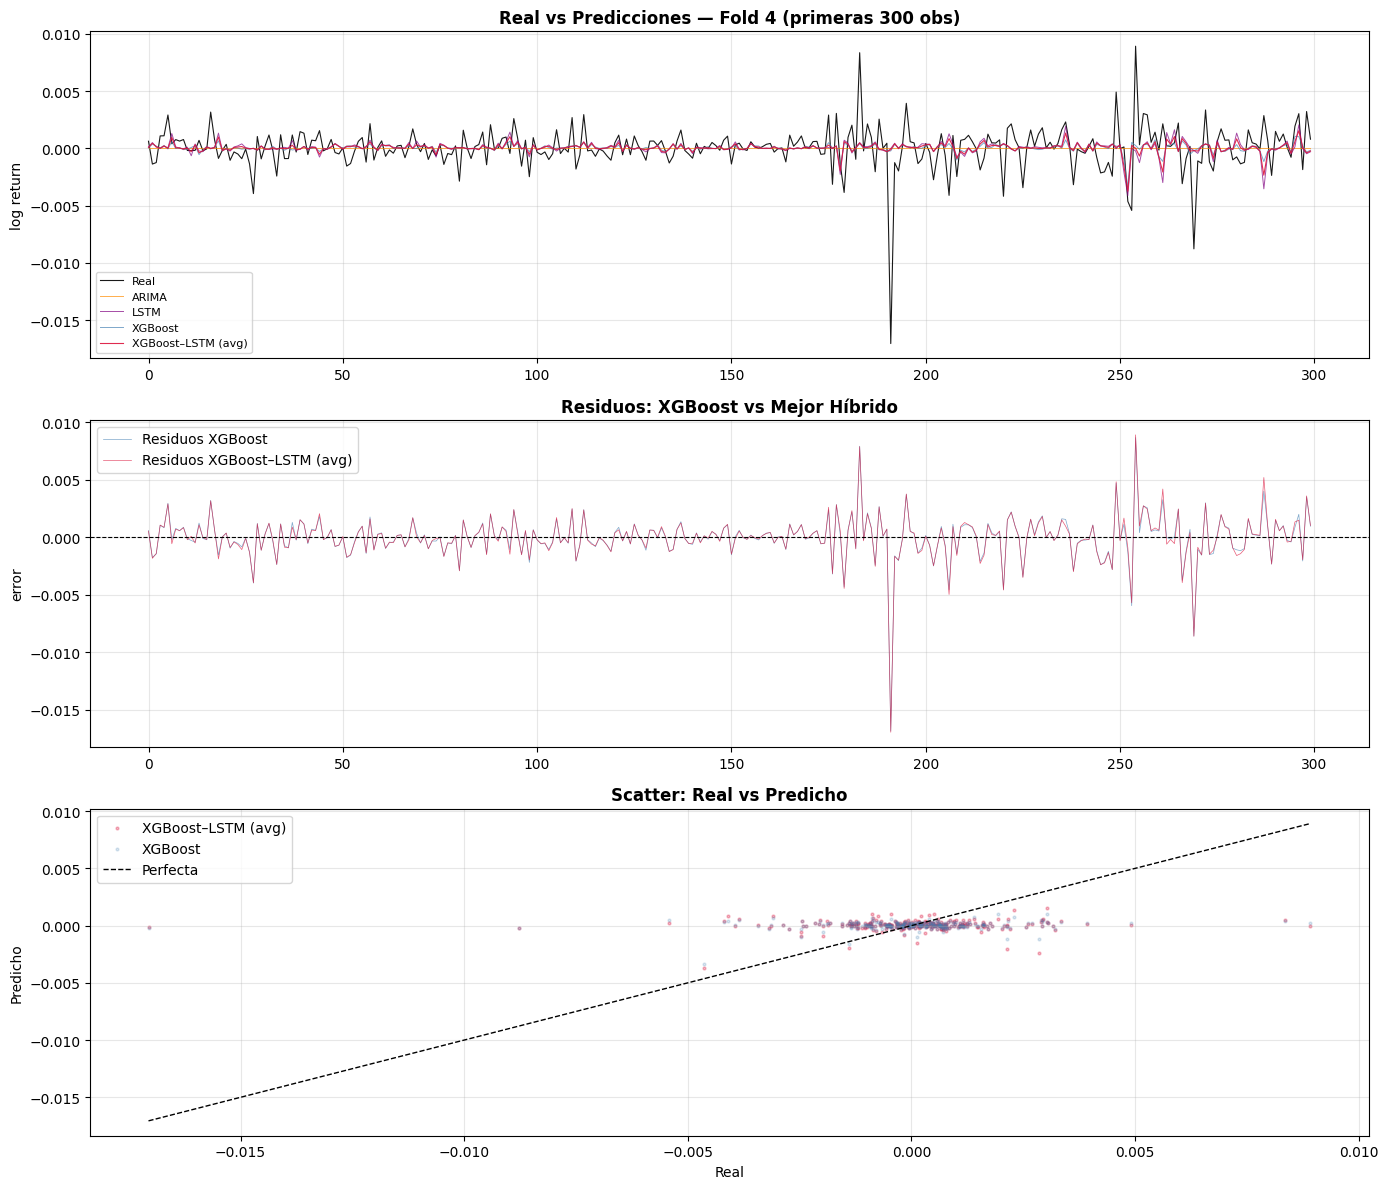

In [22]:
# ── Predicciones del mejor híbrido ───────────────────────────────────────
fold_vis = len(X) - 1
while len(mejor_preds[fold_vis]) == 0 and fold_vis > 0:
    fold_vis -= 1

n_vis   = min(300, len(mejor_real[fold_vis]))
y_real  = mejor_real[fold_vis][:n_vis]
y_hybr  = mejor_preds[fold_vis][:n_vis]
y_arima = arima_preds_folds[fold_vis][:n_vis]
y_lstm  = lstm_preds_folds[fold_vis][:n_vis]
y_xgb   = xgb_preds_folds[fold_vis][:n_vis]

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

axes[0].plot(y_real,  label='Real',         color='black',     linewidth=0.8, alpha=0.9)
axes[0].plot(y_arima, label='ARIMA',         color='darkorange',linewidth=0.7, alpha=0.7)
axes[0].plot(y_lstm,  label='LSTM',          color='purple',    linewidth=0.7, alpha=0.7)
axes[0].plot(y_xgb,   label='XGBoost',       color='steelblue', linewidth=0.7, alpha=0.7)
axes[0].plot(y_hybr,  label=mejor_name,      color='crimson',   linewidth=0.8, alpha=0.9)
axes[0].set_title(f'Real vs Predicciones — Fold {fold_vis} (primeras {n_vis} obs)', fontweight='bold')
axes[0].set_ylabel('log return')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

res_hybrid = y_real - y_hybr
res_xgb    = y_real - y_xgb
axes[1].plot(res_xgb,    label='Residuos XGBoost',     color='steelblue', linewidth=0.5, alpha=0.7)
axes[1].plot(res_hybrid, label=f'Residuos {mejor_name}', color='crimson', linewidth=0.5, alpha=0.7)
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('Residuos: XGBoost vs Mejor Híbrido', fontweight='bold')
axes[1].set_ylabel('error')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

lims = [min(y_real.min(), y_hybr.min()), max(y_real.max(), y_hybr.max())]
axes[2].scatter(y_real, y_hybr, alpha=0.3, s=4, color='crimson',   label=mejor_name)
axes[2].scatter(y_real, y_xgb,  alpha=0.2, s=4, color='steelblue', label='XGBoost')
axes[2].plot(lims, lims, 'k--', linewidth=1, label='Perfecta')
axes[2].set_xlabel('Real')
axes[2].set_ylabel('Predicho')
axes[2].set_title('Scatter: Real vs Predicho', fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


En el gráfico de Real vs Predicciones sobre el Fold 4 se observa que todos los modelos, incluyendo el mejor híbrido XGBoost–LSTM (avg), siguen de cerca la serie real en periodos de baja volatilidad pero fallan en capturar la magnitud de los movimientos extremos alrededor de las observaciones 190 y 260. En el gráfico de residuos, XGBoost–LSTM (avg) y XGBoost presentan patrones prácticamente idénticos, confirmando que el promedio con LSTM no introduce diferencias sustanciales en el comportamiento del error. El scatter muestra que ambos modelos concentran sus predicciones cerca de cero con una dispersión simétrica, evidenciando la tendencia general de los modelos a suavizar los retornos extremos.

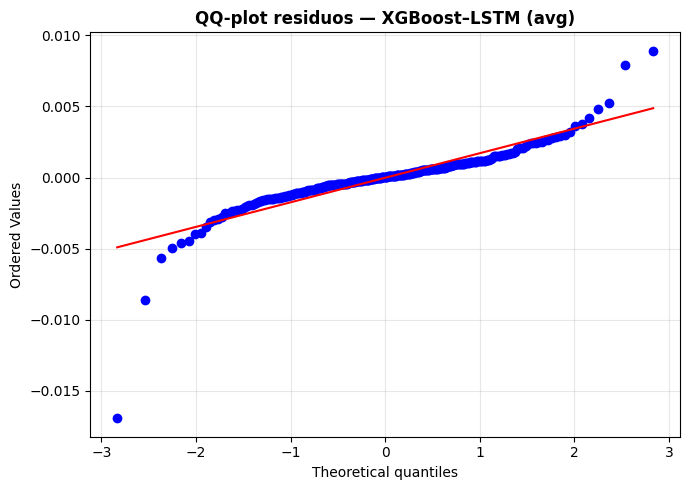

In [23]:
# ── QQ-plot residuos mejor híbrido ───────────────────────────────────────
from scipy.stats import probplot

fig, ax = plt.subplots(figsize=(7, 5))
probplot(res_hybrid, dist='norm', plot=ax)
ax.set_title(f'QQ-plot residuos — {mejor_name}', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


El QQ-plot de los residuos del mejor híbrido muestra que la distribución sigue la línea teórica normal de manera razonablemente ajustada en la zona central, pero presenta desviaciones importantes en ambas colas. Los valores extremos negativos se alejan considerablemente de la línea teórica, confirmando la presencia de colas pesadas en los residuos y la incapacidad del modelo para capturar completamente los eventos de alta volatilidad del mercado del Bitcoin. Este comportamiento es consistente con lo observado en el análisis de residuos del BPP.

## Test de Diebold-Mariano | Mejor Híbrido vs Mejor Benchmark

Comparación estadística entre el mejor híbrido y el mejor modelo del BPP benchmark.

In [35]:
from scipy.stats import t as t_dist

def diebold_mariano(e1, e2, h=1):
    d      = e1**2 - e2**2
    T      = len(d)
    d_bar  = np.mean(d)
    gamma0 = np.var(d, ddof=1)
    gammas = [np.cov(d[k:], d[:-k])[0, 1] for k in range(1, h)] if h > 1 else []
    V_d    = (gamma0 + 2 * sum(gammas)) / T
    if V_d <= 0:
        return np.nan, np.nan, d_bar
    DM_stat = d_bar / np.sqrt(V_d)
    hln     = np.sqrt((T + 1 - 2*h + h*(h-1)/T) / T)
    DM_c    = DM_stat * hln
    p_valor = 2 * (1 - t_dist.cdf(abs(DM_c), df=T - 1))
    return DM_c, p_valor, d_bar

preds_bm = np.load('outputs/benchmark_best_preds.npy')
real_bm  = np.load('outputs/benchmark_real.npy')

preds_hyb = np.load('outputs/hybrid_best_preds.npy')
real_hyb  = np.load('outputs/hybrid_real.npy')

n         = min(len(preds_bm), len(preds_hyb), len(real_bm), len(real_hyb))
real_dm   = real_hyb[-n:]
preds_bm  = preds_bm[-n:]
preds_hyb = preds_hyb[-n:]

e_bm  = real_dm - preds_bm
e_hyb = real_dm - preds_hyb

rmse_bm  = np.sqrt(np.mean(e_bm**2))
rmse_hyb = np.sqrt(np.mean(e_hyb**2))

dm_stat, p_val, d_bar = diebold_mariano(e_bm, e_hyb)



conclusion = ('Híbrido significativamente mejor'    if p_val < 0.05 and d_bar > 0 else
              'Benchmark significativamente mejor'   if p_val < 0.05 and d_bar < 0 else
              'Sin diferencia estadísticamente significativa')

df_metricas = pd.DataFrame([
    {'Modelo': 'Mejor Benchmark', 
     'RMSE (test)': rmse_bm, 
     'MAE (test)' : mae_fn(real_dm, preds_bm)},
    {'Modelo': mejor_name,              
     'RMSE (test)': round(rmse_hyb, 6), 
     'MAE (test)' : round(float(np.mean(np.abs(e_hyb))), 6)},
])

df_dm_stat = pd.DataFrame([{
    'Modelo A'         : 'Mejor Benchmark',
    'Modelo B'         : mejor_name,
    'Dif. pérdida (d̄)' : f'{d_bar:.2e}',
    'DM estadístico'   : round(dm_stat, 3),
    'p-valor'          : round(p_val,   4),
    'Conclusión'       : conclusion
}])

table_styles = [
    {'selector': 'thead th',
     'props': [('background-color', '#2c3e50'), ('color', 'white'),
               ('font-weight', 'bold'), ('text-align', 'center'), ('padding', '8px')]},
    {'selector': 'tbody td',
     'props': [('text-align', 'center'), ('padding', '6px')]},
    {'selector': 'tbody tr:nth-child(even)',
     'props': [('background-color', '#293138')]},
]

def color_pval(val):
    if isinstance(val, float):
        return 'color: #2ecc71; font-weight: bold' if val < 0.05 else 'color: #e74c3c'
    return ''

print('── Métricas comparativas ─────────────────────────────────────────────────')
display(df_metricas.style.set_table_styles(table_styles).hide(axis='index'))
print()
print('── Test de Diebold-Mariano ───────────────────────────────────────────────')
display(
    df_dm_stat.style
    .map(color_pval, subset=['p-valor'])
    .set_caption(f'Test Diebold-Mariano — {mejor_name} vs Mejor Benchmark')
    .set_table_styles(table_styles)
    .hide(axis='index')
)

df_dm_stat.to_csv('outputs/dm_3hibridos_vs_benchmark.csv', index=False)
print(f'\nConclusión: {conclusion}')
print(f'DM stat: {dm_stat:.3f} | p-valor: {p_val:.4f} | d_bar: {d_bar:.2e}')
print('Exportado a outputs/dm_3hibridos_vs_benchmark.csv')


── Métricas comparativas ─────────────────────────────────────────────────


Modelo,RMSE (test),MAE (test)
Mejor Benchmark,0.002698,0.001610
XGBoost–LSTM (avg),0.002676,0.001593



── Test de Diebold-Mariano ───────────────────────────────────────────────


Modelo A,Modelo B,Dif. pérdida (d̄),DM estadístico,p-valor,Conclusión
Mejor Benchmark,XGBoost–LSTM (avg),1.18e-07,2.413000,0.015800,Híbrido significativamente mejor



Conclusión: Híbrido significativamente mejor
DM stat: 2.413 | p-valor: 0.0158 | d_bar: 1.18e-07
Exportado a outputs/dm_3hibridos_vs_benchmark.csv


El test de Diebold-Mariano comparó el mejor híbrido global, XGBoost–LSTM (avg), contra el mejor modelo del BPP. El estadístico DM de 2.413 con un p-valor de 0.0158 indica que la diferencia en precisión predictiva entre ambos modelos es estadísticamente significativa al nivel del 5%. La diferencia de pérdida positiva (d̄ = 1.18e-07) confirma que el benchmark incurrió en mayores errores cuadráticos que el híbrido, por lo que la conclusión es que XGBoost–LSTM (avg) fue significativamente más preciso que el mejor benchmark del BPP.

In [34]:
# ── Exportar mejor modelo híbrido para deploy ─────────────────────────────
import joblib

# El mejor híbrido es XGBoost–LSTM (avg) — no tiene parámetros entrenables,
# solo necesita los modelos base: XGBoost y LSTM
deploy_package = {
    'tipo'             : 'average',
    'nombre'           : mejor_name,
    'modelos_base'     : ['xgboost', 'lstm'],
    'xgb_params'       : mejor_params_xgb,
    'lstm_params'      : mejor_params_lstm,
    'lstm_models'      : lstm_models,       # modelos LSTM por fold
    'xgb_preds_folds'  : xgb_preds_folds,
    'lstm_preds_folds' : lstm_preds_folds,
    'cache_folds'      : cache_folds,       # scalers por fold
    'N_LAGS'           : N_LAGS,
    'RANDOM_SEED'      : RANDOM_SEED,
    'rmse'             : round(rmse_hyb, 6),
    'mae'              : round(float(np.mean(np.abs(e_hyb))), 6),
}

# ── Guardar predicciones híbridas finales ─────────────────────────

preds_hyb = np.concatenate([
    p for p in mejor_preds if len(p) > 0
])

real_hyb = np.concatenate([
    r for r in mejor_real if len(r) > 0
])

np.save('outputs/hybrid_best_preds.npy', preds_hyb)
np.save('outputs/hybrid_real.npy', real_hyb)

print('✅ Predicciones híbridas exportadas')

joblib.dump(deploy_package, 'outputs/mejor_hibrido_deploy.joblib')
print(f'✅ Modelo exportado: outputs/mejor_hibrido_deploy.joblib')
print(f'   Nombre  : {mejor_name}')
print(f'   RMSE    : {deploy_package["rmse"]}')
print(f'   MAE     : {deploy_package["mae"]}')
print(f'   Folds   : {sum(m is not None for m in lstm_models)}')

✅ Predicciones híbridas exportadas
✅ Modelo exportado: outputs/mejor_hibrido_deploy.joblib
   Nombre  : XGBoost–LSTM (avg)
   RMSE    : 0.002676
   MAE     : 0.001593
   Folds   : 5
